# Introducción

# Preparación de los datos

Importamos nuestras librerías y cargamos los DataFrames

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from scipy import stats as st

In [3]:
hypotheses = pd.read_csv("datasets/hypotheses_us.csv", sep=";")
orders = pd.read_csv("datasets/orders_us.csv")
visits = pd.read_csv("datasets/visits_us.csv")

# Exploración de los datos

Utilizamos los métodos .info(), .head() y .tail() en cada uno de nuestros DataFrames para familiarizarnos con nuestros datos y buscamos duplicados en los DataFrames `orders` y `visits`

## hypotheses

In [4]:
hypotheses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Hypothesis  9 non-null      object
 1   Reach       9 non-null      int64 
 2   Impact      9 non-null      int64 
 3   Confidence  9 non-null      int64 
 4   Effort      9 non-null      int64 
dtypes: int64(4), object(1)
memory usage: 492.0+ bytes


In [5]:
hypotheses.head()

,Hypothesis,Reach,Impact,Confidence,Effort
0,Add two new channels for attracting traffic. T...,3,10,8,6
1,Launch your own delivery service. This will sh...,2,5,4,10
2,Add product recommendation blocks to the store...,8,3,7,3
3,Change the category structure. This will incre...,8,3,3,8
4,Change the background color on the main page. ...,3,1,1,1


In [6]:
hypotheses.tail()

,Hypothesis,Reach,Impact,Confidence,Effort
4,Change the background color on the main page. ...,3,1,1,1
5,Add a customer review page. This will increase...,3,2,2,3
6,Show banners with current offers and sales on ...,5,3,8,3
7,Add a subscription form to all the main pages....,10,7,8,5
8,Launch a promotion that gives users discounts ...,1,9,9,5


El DataFrame contiene diferentes hipótesis planteadas por el departamento de marketing junto con calificaciones en una escala del 1 al 10 de su alcance, impacto, confianza en que funcionara y esfuerzo que conllevara realizar la acción citada.

Los nombres de las columnas deberán pasarse a minúsculas.

## orders

In [7]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   transactionId  1197 non-null   int64  
 1   visitorId      1197 non-null   int64  
 2   date           1197 non-null   object 
 3   revenue        1197 non-null   float64
 4   group          1197 non-null   object 
dtypes: float64(1), int64(2), object(2)
memory usage: 46.9+ KB


In [8]:
orders.head()

,transactionId,visitorId,date,revenue,group
0,3667963787,3312258926,2019-08-15,30.4,B
1,2804400009,3642806036,2019-08-15,15.2,B
2,2961555356,4069496402,2019-08-15,10.2,A
3,3797467345,1196621759,2019-08-15,155.1,B
4,2282983706,2322279887,2019-08-15,40.5,B


In [9]:
orders.tail()

,transactionId,visitorId,date,revenue,group
1192,2662137336,3733762160,2019-08-14,100.8,B
1193,2203539145,370388673,2019-08-14,50.1,A
1194,1807773912,573423106,2019-08-14,165.3,A
1195,1947021204,1614305549,2019-08-14,5.5,A
1196,3936777065,2108080724,2019-08-15,3120.1,B


Buscamos datos duplicados

In [10]:
orders.duplicated().sum()

np.int64(0)

In [11]:
# Agrupamos nuestro dataframe por visitante y buscamos cuantos grupos unicos tiene cada uno
users_in_both_groups = orders.groupby("visitorId")["group"].nunique()

# Filtramos a los usuarios que aparecen en más de un grupo
users_in_both_groups = users_in_both_groups[users_in_both_groups > 1]

print(f"Usuarios en ambos grupos: {len(users_in_both_groups)}")

Usuarios en ambos grupos: 58


El dataframe `orders` contiene información sobre las compras realizadas por usuarios divididos en dos grupos (A y B). Consta de 1197 registros y 5 columnas a las cuales debemos renombrar para que cumplan con el formato snake_case (`transactionId`, `visitorId`, `date`, `revenue`, `group`) 

También es necesario convertir el tipo de datos de la columna `date` a datetime. 

No existen duplicados explícitos pero existen 58 usuarios que aparecen en ambos grupos.

## visits

In [12]:
visits.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    62 non-null     object
 1   group   62 non-null     object
 2   visits  62 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 1.6+ KB


In [13]:
visits.head()

,date,group,visits
0,2019-08-01,A,719
1,2019-08-02,A,619
2,2019-08-03,A,507
3,2019-08-04,A,717
4,2019-08-05,A,756


In [14]:
visits.tail()

,date,group,visits
57,2019-08-27,B,720
58,2019-08-28,B,654
59,2019-08-29,B,531
60,2019-08-30,B,490
61,2019-08-31,B,718


In [15]:
visits.duplicated().sum()

np.int64(0)

El DataFrame `visits` contiene el registro de las visitas realizadas por los usuarios de cada grupo por día.

No existen valores duplicados. 

Es necesario cambiar le tipo de datos de la columna `date` a datetime

# Procesamiento de los datos

## hypotheses

Cambiamos el nombre de las columnas del DataFrame `hypotheses`

In [16]:
hypotheses.columns = hypotheses.columns.str.lower()

hypotheses.columns

Index(['hypothesis', 'reach', 'impact', 'confidence', 'effort'], dtype='object')

## orders

Cambiamos el nombre de las columnas del DataFrame `orders`

In [17]:
orders.columns = ["transaction_id", "visitor_id", "date", "revenue", "group"]

orders.columns

Index(['transaction_id', 'visitor_id', 'date', 'revenue', 'group'], dtype='object')

Cambiamos el tipo de datos de la columna `date`

In [18]:
orders["date"] = pd.to_datetime(orders["date"])

print(orders["date"].dtype)

datetime64[ns]


Filtramos a los usuarios que aparecen en ambos grupos 

In [19]:
orders_clean = orders[~orders["visitor_id"].isin(users_in_both_groups.index)]

In [20]:
# Revisamos la cantidad de usuarios en cada grupo después de la limpieza
users_by_group = orders_clean.groupby("group")["visitor_id"].nunique()

print(users_by_group)

group
A    445
B    528
Name: visitor_id, dtype: int64


Tras eliminar los 58 usuarios contaminados, el grupo A quedó con 445 usuarios únicos y el grupo B con 528. La diferencia es aceptable para continuar con el análisis.

## visits

Cambiamos el tipo de datos de la columna `date`

In [21]:
visits["date"] = pd.to_datetime(visits["date"])

print(visits["date"].dtype)

datetime64[ns]


# Parte 1: Priorización de hipótesis

In [22]:
hypotheses.columns

Index(['hypothesis', 'reach', 'impact', 'confidence', 'effort'], dtype='object')

## Framework ICE

In [23]:
# Agregamos la columna "ice" con el calculo correspondiente

hypotheses["ice"] = hypotheses["impact"] * hypotheses["confidence"] / hypotheses["effort"]

hypotheses.sort_values(by="ice", ascending=False)

,hypothesis,reach,impact,confidence,effort,ice
8,Launch a promotion that gives users discounts ...,1,9,9,5,16.200000
0,Add two new channels for attracting traffic. T...,3,10,8,6,13.333333
7,Add a subscription form to all the main pages....,10,7,8,5,11.200000
6,Show banners with current offers and sales on ...,5,3,8,3,8.000000
2,Add product recommendation blocks to the store...,8,3,7,3,7.000000
1,Launch your own delivery service. This will sh...,2,5,4,10,2.000000
5,Add a customer review page. This will increase...,3,2,2,3,1.333333
3,Change the category structure. This will incre...,8,3,3,8,1.125000
4,Change the background color on the main page. ...,3,1,1,1,1.000000


## Framework RICE

In [24]:
# Agregamos la columna "rice" con el calculo correspondiente

hypotheses["rice"] = hypotheses["reach"] * hypotheses["impact"] * hypotheses["confidence"] / hypotheses["effort"]

hypotheses.sort_values(by="rice", ascending=False)

,hypothesis,reach,impact,confidence,effort,ice,rice
7,Add a subscription form to all the main pages....,10,7,8,5,11.200000,112.0
2,Add product recommendation blocks to the store...,8,3,7,3,7.000000,56.0
0,Add two new channels for attracting traffic. T...,3,10,8,6,13.333333,40.0
6,Show banners with current offers and sales on ...,5,3,8,3,8.000000,40.0
8,Launch a promotion that gives users discounts ...,1,9,9,5,16.200000,16.2
3,Change the category structure. This will incre...,8,3,3,8,1.125000,9.0
1,Launch your own delivery service. This will sh...,2,5,4,10,2.000000,4.0
5,Add a customer review page. This will increase...,3,2,2,3,1.333333,4.0
4,Change the background color on the main page. ...,3,1,1,1,1.000000,3.0


## Conclusión

La priorización cambia significativamente al incorporar el factor de alcance en RICE. La hipótesis 8, que lidera el ranking ICE por su alto impacto y confianza, cae al quinto lugar en RICE debido a su alcance mínimo (1/10). En contraste, la hipótesis 7 sube al primer lugar porque combina alto alcance (10/10) con buen impacto y confianza.

Para una tienda online donde el objetivo es maximizar ingresos a escala, RICE es el framework más adecuado ya que una hipótesis de alto impacto pero bajo alcance genera menos valor de negocio que una de impacto moderado pero alcance masivo.

# Parte 2: Análisis del test A/B

## Ingreso acumulado por grupo

Para esta parte del análisis crearemos el DataFrame `cumulative_data` el cual contendrá información sobre los ingresos y visitantes acumulados de cada grupo

Para obtener los ingresos acumulados de cada grupo comenzaremos por crear una matriz que contenga pares de grupos y fechas sin duplicados

In [26]:
date_groups = orders[["date", "group"]].drop_duplicates()

Realizamos el calculo de los ingresos acumulados apoyandonos de las funciones *lambda* y *np.logical_and()*

In [27]:
orders_aggregated = date_groups.apply(lambda x: orders[np.logical_and(orders["date"] <= x["date"], orders["group"] == x["group"])].agg(
    {"date": "max", "group": "max", "transaction_id": pd.Series.nunique, "visitor_id": pd.Series.nunique, "revenue": "sum"}
), axis=1).sort_values(by=["date", "group"])

Seguimos el mismo proceso para las visitas

In [29]:
visits_aggregated = date_groups.apply(lambda x: visits[np.logical_and(visits["date"] <= x["date"], visits["group"] == x["group"])].agg(
    {"date": "max", "group": "max", "visits": "sum"}
), axis=1).sort_values(by=["date", "group"])

Unimos ambos DataFrames en uno solo: `cumulative_data`

In [30]:
cumulative_data = orders_aggregated.merge(visits_aggregated, left_on=["date", "group"], right_on=["date", "group"])

cumulative_data.columns = ["date", "group", "orders", "buyers", "revenue", "visits"]

A continuación, creamos nuestro gráfico de ingresos acumulados

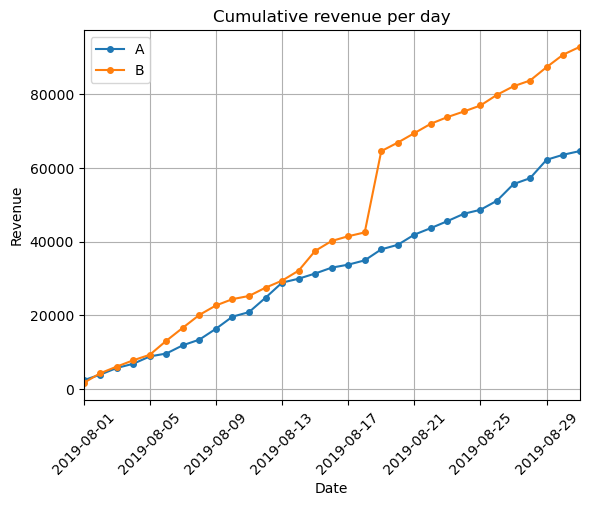

In [48]:
# DataFrame con pedidos e ingresos acumulados por dia del grupo A
cumulative_revenue_a = cumulative_data[cumulative_data["group"] == "A"][["date", "revenue","orders"]]

# DataFrame con pedidos e ingresos acumulados por dia del grupo B
cumulative_revenue_B = cumulative_data[cumulative_data["group"] == "B"][["date", "revenue","orders"]]

# Generamos el gráfico

plt.plot(cumulative_revenue_a["date"], cumulative_revenue_a["revenue"], marker="o", markersize=4, label="A")
plt.plot(cumulative_revenue_B["date"], cumulative_revenue_B["revenue"], marker="o", markersize=4, label="B")

plt.title("Cumulative revenue per day")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.xlim(pd.Timestamp("2019-08-01"), pd.Timestamp("2019-08-31"))
plt.grid()
plt.legend()



plt.show()